# ROSSMANN STORE SALES PREDICTION - PREPROCESSING & EDA

**Dataset**: Rossmann Store Sales (Kaggle)  
**Topik**: Prediksi Penjualan Harian Toko Retail  
**Target**: Sales (penjualan harian)

**Tahapan**:
1. Data Loading & Understanding
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Normalisasi & Split Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

### Path Setup

In [2]:
# Gunakan path relatif dari root proyek
BASE_DIR   = ".."
DATA_DIR   = os.path.join(BASE_DIR, 'data')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
DOCS_DIR   = os.path.join(BASE_DIR, 'docs', '01_preprocessing_eda')


os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

### STEP 1: Load Dataset

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), low_memory=False)
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'), low_memory=False)
store_df = pd.read_csv(os.path.join(DATA_DIR, 'store.csv'))

print(f"Dataset Train dimuat: {train_df.shape}")
print(f"Dataset Test dimuat: {test_df.shape}")
print(f"Dataset Store dimuat: {store_df.shape}")

Dataset Train dimuat: (1017209, 9)
Dataset Test dimuat: (41088, 8)
Dataset Store dimuat: (1115, 10)


### STEP 2: Understanding Dataset

In [4]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### STEP 3: Data Preprocessing

In [6]:
train = train_df.copy()
test  = test_df.copy()
store = store_df.copy()

# Merge Data
train = train.merge(store, on='Store', how='left')
test  = test.merge(store, on='Store', how='left')

# Handle Missing Values
train['CompetitionDistance'] = train['CompetitionDistance'].fillna(train['CompetitionDistance'].median())
train['CompetitionOpenSinceMonth'] = train['CompetitionOpenSinceMonth'].fillna(0)
train['CompetitionOpenSinceYear'] = train['CompetitionOpenSinceYear'].fillna(0)
train['Promo2SinceWeek'] = train['Promo2SinceWeek'].fillna(0)
train['Promo2SinceYear'] = train['Promo2SinceYear'].fillna(0)
train['PromoInterval'] = train['PromoInterval'].fillna('None')

test['CompetitionDistance'] = test['CompetitionDistance'].fillna(test['CompetitionDistance'].median())
test['CompetitionOpenSinceMonth'] = test['CompetitionOpenSinceMonth'].fillna(0)
test['CompetitionOpenSinceYear'] = test['CompetitionOpenSinceYear'].fillna(0)
test['Promo2SinceWeek'] = test['Promo2SinceWeek'].fillna(0)
test['Promo2SinceYear'] = test['Promo2SinceYear'].fillna(0)
test['PromoInterval'] = test['PromoInterval'].fillna('None')
test['Open'] = test['Open'].fillna(1)

# Filter: Hanya toko yang buka (Sales > 0)
train = train[train['Sales'] > 0]

# Feature Engineering: Date
train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])

def extract_date_features(df):
    df['Year']       = df['Date'].dt.year
    df['Month']      = df['Date'].dt.month
    df['Day']        = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Quarter']    = df['Date'].dt.quarter
    return df

train = extract_date_features(train)
test  = extract_date_features(test)

# Categorical Encoding
state_holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
train['StateHoliday'] = train['StateHoliday'].map(state_holiday_map).fillna(0).astype(int)
test['StateHoliday']  = test['StateHoliday'].map(state_holiday_map).fillna(0).astype(int)

store_type_map = {'a': 0, 'b': 1, 'c': 2, 'd': 3}
train['StoreType'] = train['StoreType'].map(store_type_map)
test['StoreType']  = test['StoreType'].map(store_type_map)

assortment_map = {'a': 0, 'b': 1, 'c': 2}
train['Assortment'] = train['Assortment'].map(assortment_map)
test['Assortment']  = test['Assortment'].map(assortment_map)

# Drop unused columns
cols_to_drop_train = ['Date', 'Customers', 'PromoInterval']
cols_to_drop_test  = ['Date', 'PromoInterval']
train = train.drop(columns=cols_to_drop_train, errors='ignore')
test  = test.drop(columns=cols_to_drop_test, errors='ignore')

### STEP 4: Exploratory Data Analysis (EDA)

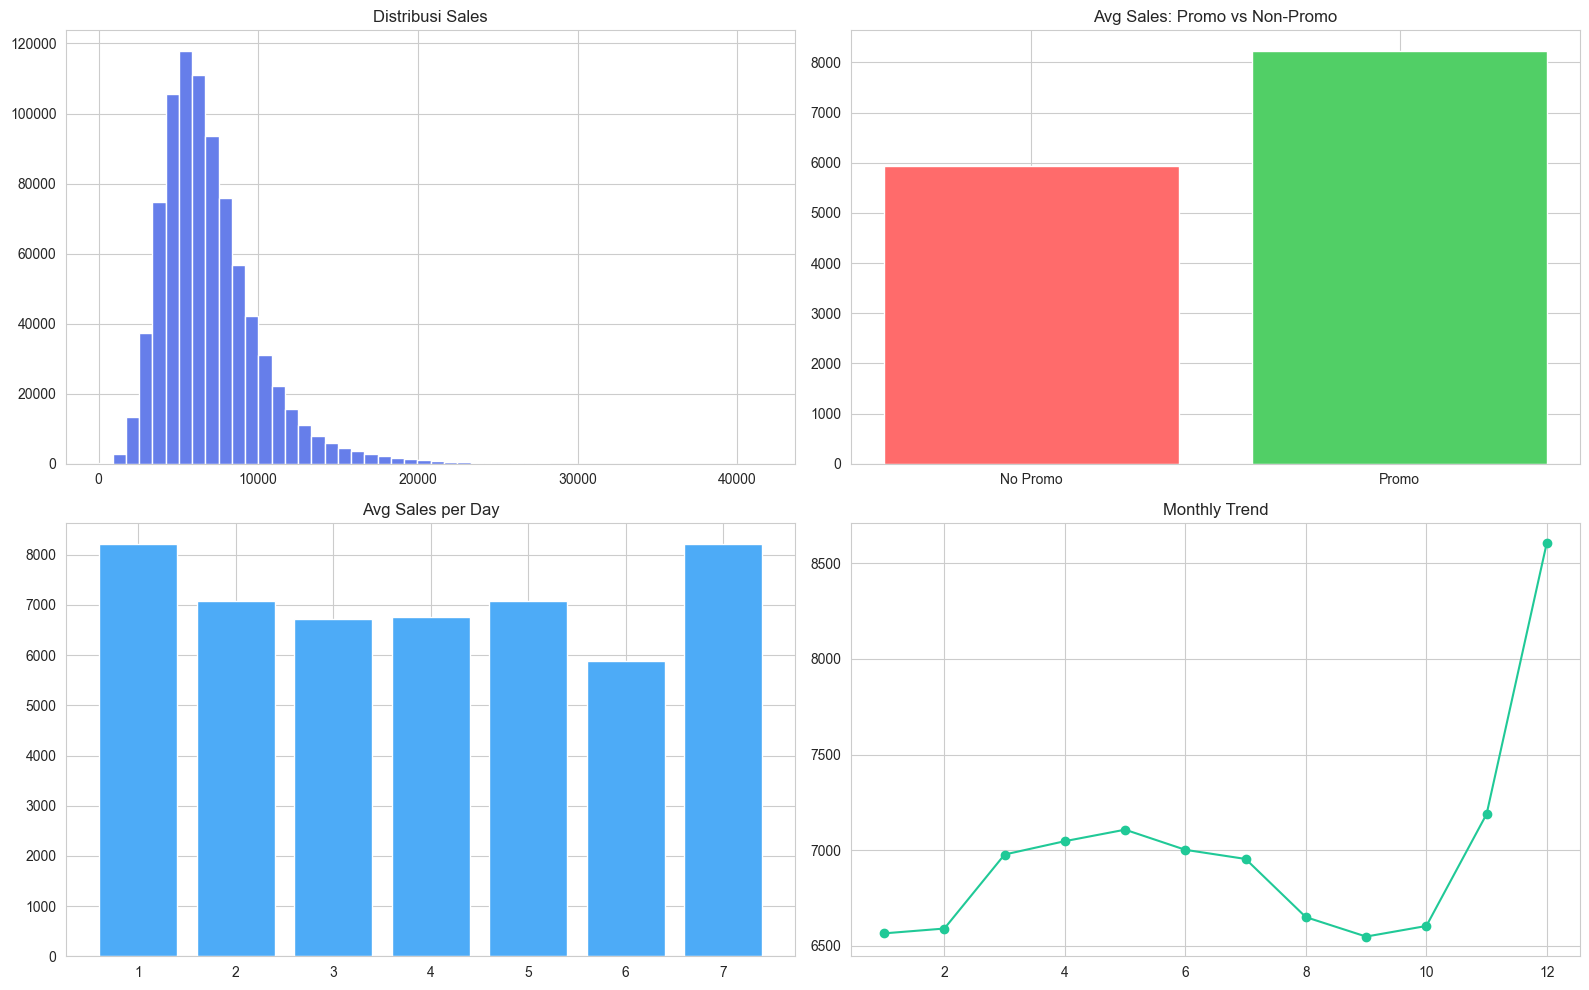

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribusi Sales
axes[0, 0].hist(train['Sales'], bins=50, color='#667eea', edgecolor='white')
axes[0, 0].set_title('Distribusi Sales')

# 2. Promo Impact
promo_sales = train.groupby('Promo')['Sales'].mean()
axes[0, 1].bar(['No Promo', 'Promo'], promo_sales.values, color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_title('Avg Sales: Promo vs Non-Promo')

# 3. Day of Week
day_sales = train.groupby('DayOfWeek')['Sales'].mean()
axes[1, 0].bar(range(1, 8), day_sales.values, color='#4dabf7')
axes[1, 0].set_title('Avg Sales per Day')

# 4. Monthly Trend
month_sales = train.groupby('Month')['Sales'].mean()
axes[1, 1].plot(month_sales.index, month_sales.values, marker='o', color='#20c997')
axes[1, 1].set_title('Monthly Trend')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, '01_eda_visualization.png'))
plt.show()


### STEP 5: Normalisasi & Split Data

In [8]:
X = train.drop(['Sales'], axis=1)
y = train['Sales']
feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Splitting & Normalization Done")

Splitting & Normalization Done


### STEP 6: Simpan Data Preprocessing

In [9]:
preprocessing_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'scaler': scaler,
    'feature_columns': feature_columns,
    'store_type_map': store_type_map,
    'assortment_map': assortment_map,
    'state_holiday_map': state_holiday_map,
}

save_path = os.path.join(MODEL_DIR, 'preprocessing_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(preprocessing_data, f)

print(f"Data disimpan ke: {save_path}")

Data disimpan ke: ..\models\preprocessing_data.pkl


In [10]:
# Data Time Series untuk LSTM
train_ts = train_df.copy()
train_ts['Date'] = pd.to_datetime(train_ts['Date'])
train_ts = train_ts[train_ts['Sales'] > 0]
daily_sales = train_ts.groupby('Date')['Sales'].mean().sort_index()

ts_data = {'daily_sales': daily_sales}
ts_path = os.path.join(MODEL_DIR, 'timeseries_data.pkl')
with open(ts_path, 'wb') as f:
    pickle.dump(ts_data, f)
print(f"Time series data disimpan ke: {ts_path}")

Time series data disimpan ke: ..\models\timeseries_data.pkl


### STEP 5: Correlation Matrix

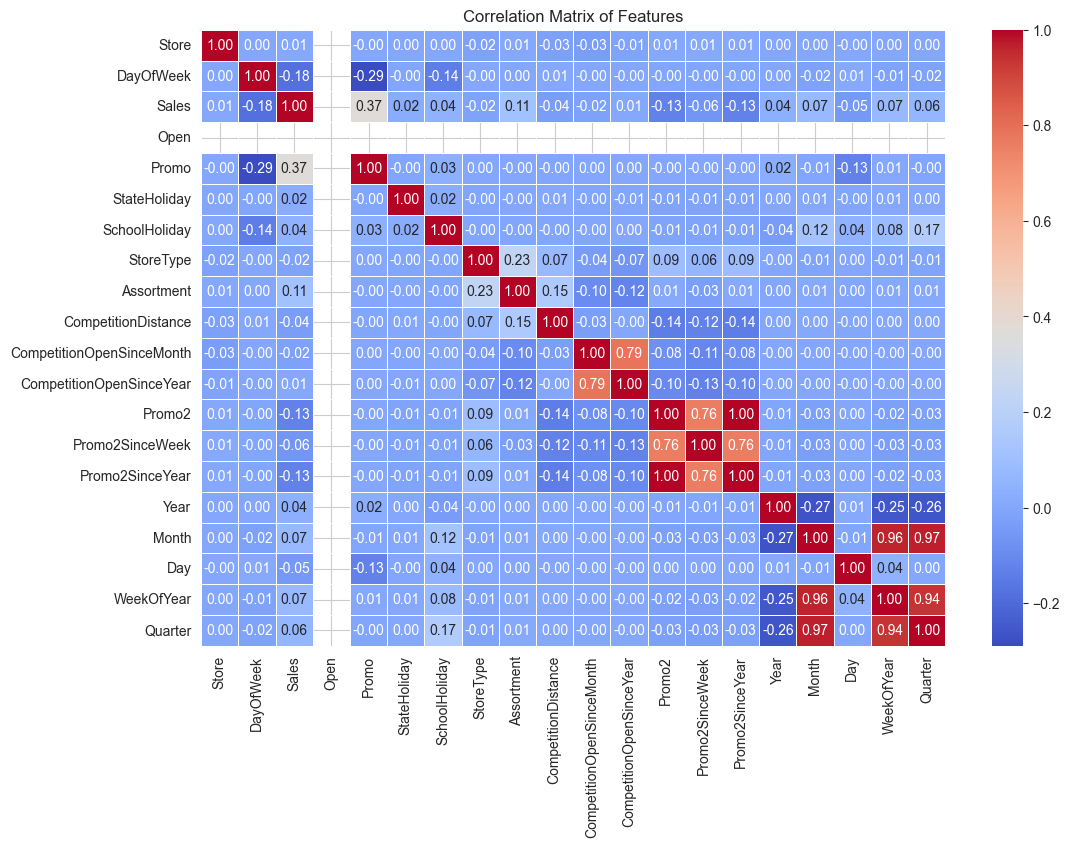

In [11]:
### STEP 5: Correlation Matrix
plt.figure(figsize=(12, 8))
correlation = train.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.savefig(os.path.join(DOCS_DIR, '02_correlation_matrix.png'))
plt.show()